In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import joblib as joblib
import importlib as importlib
import scipy as sp
import qutip as qt
from scipy.optimize import minimize

When sent a coherent state, we would like to be able to differentiate what state is measured with a normal photodetector. This detector can either mease 0 photons or >1 photons. We would like to know if we have measured $|\alpha\rangle$ or $|-\alpha\rangle$. If the coherent states are close to each other, they will have some overlap where it becomes very hard to distinguish which signal was measured. To combat this, one can displace the incomming signal by $D(\alpha)$ or $D(-\alpha)$. This way, if one of the signals was sent, it will be displaced to the vacuum coherent $|0\rangle$ state, and the other will be displaced to $|2\alpha \rangle$. Depending on wether the photodetector measures a photon or not, it will become easier to distinguish what signal was sent.

We can visualize the Wigner function of the two coherent states $|\alpha\rangle$ and $|-\alpha\rangle$ in phase space with qutip. (Remember only one signal is sent, here both possibilities are visualized together.)

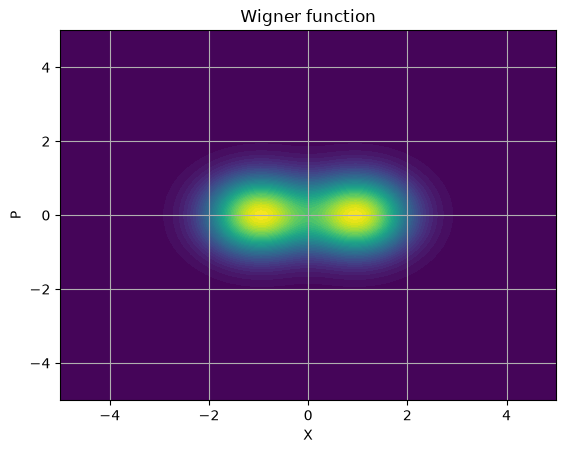

In [2]:
#coherent state from qutip
alpha = 0.7 + 0j
N = 100
coherent_state1 = qt.coherent(N, alpha)
coherent_state2 = qt.coherent(N, -alpha)
#plot in phase space
fig, ax = plt.subplots()
coherent_wigner1 = qt.wigner(coherent_state1, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
coherent_wigner2 = qt.wigner(coherent_state2, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
sum_wigner = coherent_wigner1 + coherent_wigner2
ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), sum_wigner, 50)
ax.set_xlabel('X')
ax.set_ylabel('P')
ax.set_title('Wigner function')
ax.grid()

After the displacement $D(\alpha)$ on the signal, it will be moved accordingly in phase space.

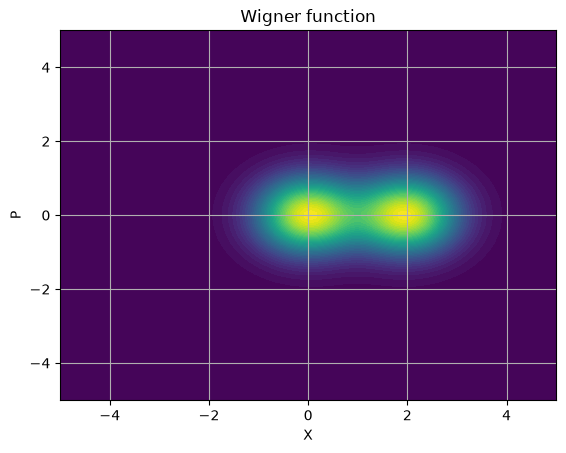

In [3]:
displace_alpha = qt.displace(N, alpha)
coherent_state1_displaced = displace_alpha * coherent_state1
coherent_state2_displaced = displace_alpha * coherent_state2
fig, ax = plt.subplots()
coherent_wigner1 = qt.wigner(coherent_state1_displaced, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
coherent_wigner2 = qt.wigner(coherent_state2_displaced, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
sum_wigner = coherent_wigner1 + coherent_wigner2
ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), sum_wigner, 50)
ax.set_xlabel('X')
ax.set_ylabel('P')
ax.set_title('Wigner function')
ax.grid()


In [4]:
def extract_alpha(coherent_state):
    a = qt.destroy(N)
    extracted_alpha = (coherent_state.dag() * a * coherent_state)
    return extracted_alpha

def kennedy_receiver(coherent1, coherent2, N):
    #extract alpha from coherent state
    alpha1 = extract_alpha(coherent1)
    alpha2 = extract_alpha(coherent2)
    #displace states by -alpha1
    displaced1 = qt.displace(N, -alpha1) * coherent1
    displaced2 = qt.displace(N, -alpha1) * coherent2
    #vacuum state
    vac_projector = qt.fock_dm(N, 0)
    prob_of_zero1 = qt.expect(vac_projector, displaced1)
    prob_of_zero2 = qt.expect(vac_projector, displaced2)
    prob_of_one1 = 1 - prob_of_zero1
    prob_of_one2 = 1 - prob_of_zero2
    #plot the before displacement and after displacement states in phase space
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))
    print(type(alpha1))
    maxR = np.max([np.abs(alpha1.real), np.abs(alpha2.real)])
    maxI = np.max([np.abs(alpha1.imag), np.abs(alpha2.imag)])
    plot_ranges_from_alpha = max(maxR, maxI) *3*np.sqrt(2)
    before_wigner1 = qt.wigner(coherent1, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    before_wigner2 = qt.wigner(coherent2, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    after_wigner1 = qt.wigner(displaced1, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    after_wigner2 = qt.wigner(displaced2, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    wigner_list = [before_wigner1, before_wigner2, after_wigner1, after_wigner2]
    for ax in [ax1, ax2, ax3, ax4]:
        ax.contourf(np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), wigner_list.pop(0), 50)
        ax.set_xlabel('X')
        ax.set_ylabel('P')
        ax.grid()
    ax1.set_title('Before displacement: State 1')
    ax2.set_title('Before displacement: State 2')
    ax3.set_title('After displacement: State 1')
    ax4.set_title('After displacement: State 2')
    print("After displacement:")
    print(f"If state 1 was sent, the probability of detecting a photon is: {prob_of_one1:.4f}")
    print(f"If state 2 was sent, the probability of detecting a photon is: {prob_of_one2:.4f}")



Here we can see how the displacement affects the signal depending on what coherent state is sent. One is moved to the vacuum state and one to a greater coherent state.

<class 'complex'>
After displacement:
If state 1 was sent, the probability of detecting a photon is: -0.0000
If state 2 was sent, the probability of detecting a photon is: 0.8647


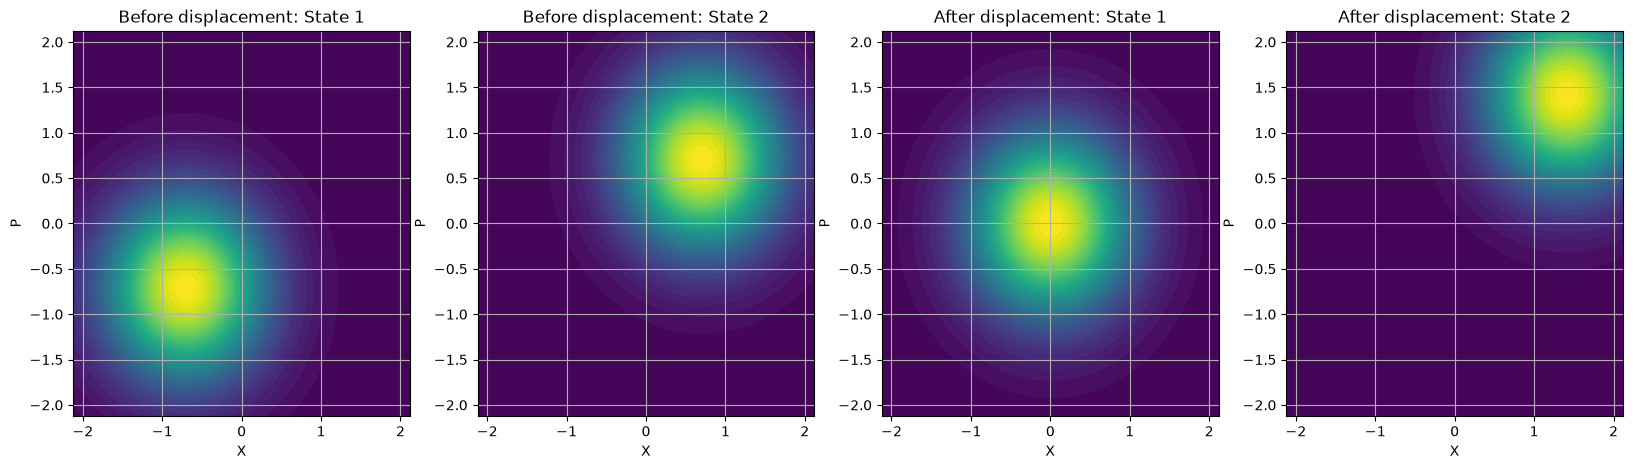

In [5]:
N = 50
alpha1 = -0.5 - 0.5j
alpha2 = 0.5 + 0.5j
coherent1 = qt.coherent(N, alpha1)
coherent2 = qt.coherent(N, alpha2)
kennedy_receiver(coherent1, coherent2, N)

Dolinar explaination

Instead of simulating the coherent states with qutip, we can calculate probabilities directly of coherent states without the package. This way we get around qutip creating big matricies and calculating on them.

Applying a displacement on a coherent state is done like so:
$$
D(-\beta)|\alpha\rangle = |\alpha -\beta\rangle = |\gamma\rangle
$$
The probability of measuring the vacuum state from this state is given as:
$$
P_0 = |\langle 0|\gamma\rangle|^2 = e^{-|\gamma|^2}
$$
If the sent state was $|\alpha\rangle$ then $\gamma=0$ and thus $P_0 = 1$. If the sent state was $|\alpha\rangle$, then $P_0 = e^{-4|\alpha|^2}$, which is not zero. The following functions splits the signal into a certain amount, then displaces the signal acoordingly.

In [6]:

def dolinar_receiver_math(alpha_signal, num_splits, dark_count_rate=0.0):
    sliced_alpha = alpha_signal / np.sqrt(num_splits)
    guess_sliced_alpha = np.abs(alpha_signal) / np.sqrt(num_splits)
    click_count = 0
    for step in range(num_splits):
        gamma = sliced_alpha - guess_sliced_alpha
        prob_0 = np.exp(-np.abs(gamma)**2)
        prob_0_actual = prob_0 * (1.0 - dark_count_rate)
        prob_click = 1.0 - prob_0_actual
        detec_click = np.random.rand() < prob_click
        if detec_click:
            click_count += 1
            guess_sliced_alpha = -guess_sliced_alpha
    final = "+alpha" if guess_sliced_alpha > 0 else "-alpha"
    return final, click_count


In [7]:
alpha = 2
N = 50
state = qt.coherent(N, alpha)
num_splits = 1
dark_count_rate = 0.05
dolinar_result, clicks = dolinar_receiver_math(alpha, num_splits, dark_count_rate)
print(f"Dolinar receiver result: {dolinar_result}, Clicks detected: {clicks}")

Dolinar receiver result: +alpha, Clicks detected: 0


It turns out that the best displacement to give from step to step is not displacing perfectly to vacuum state. Ideally it is actually best to displace a little further than the vaccum state. This way we increase alpha for the non-vacuum state, thus decreasing the probability of measureing zero photons if that state was sent. If the extra displacement is too big, then the probability of measureing photons in the zero state increases as well. There is therefore an optimal small extra displacement $\beta$ that will result in the receiver guessing the sent state correctly more often (decreasing the error probability). The following codeblocks plot simulation for finding the best $\beta$ values.

Scanning beta_0...


beta_0: 100%|██████████| 40/40 [00:01<00:00, 26.79it/s]


Scanning beta_1...


beta_1: 100%|██████████| 40/40 [00:09<00:00,  4.35it/s]


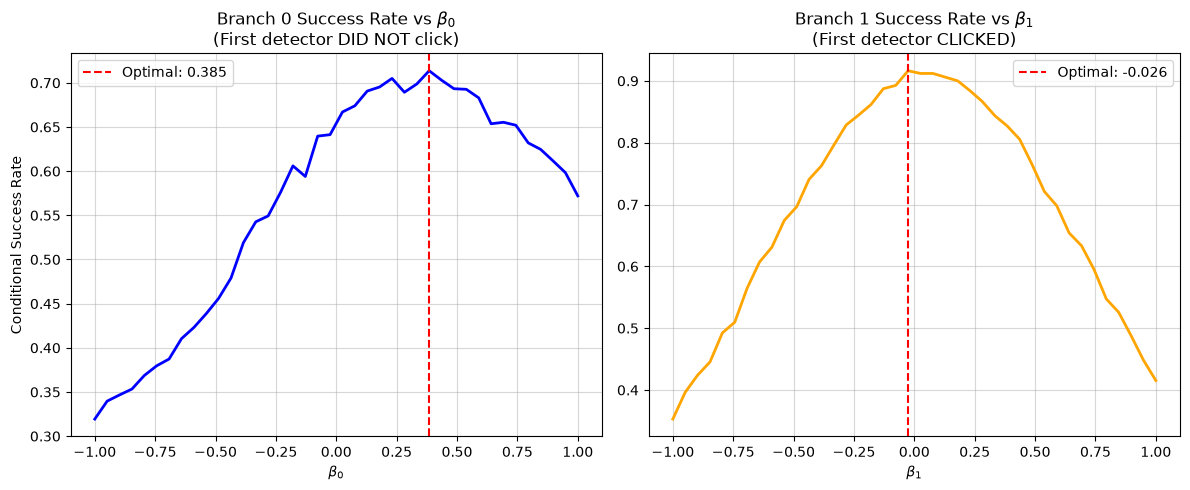

In [ ]:
def evaluate_beta_0(b0, alpha, beta_init, target_valid_runs):
    valid_runs = 0
    correct_guesses = 0
    
    while valid_runs < target_valid_runs:
        true_sign = np.random.choice([1, -1])
        slice_alpha = (true_sign * alpha) / np.sqrt(2)
        ref_alpha = alpha / np.sqrt(2)
        
        disp1 = -(ref_alpha + beta_init)
        gamma1 = slice_alpha + disp1
        prob_0_1 = np.exp(-np.abs(gamma1)**2)
        click1 = np.random.rand() > prob_0_1
        
        if not click1:
            valid_runs += 1
            disp2 = -(ref_alpha + b0)
            gamma2 = slice_alpha + disp2
            prob_0_2 = np.exp(-np.abs(gamma2)**2)
            click2 = np.random.rand() > prob_0_2
            final_guess = -1 if click2 else 1
            if final_guess == true_sign:
                correct_guesses += 1
                
    return b0, correct_guesses / target_valid_runs


def evaluate_beta_1(b1, alpha, beta_init, target_valid_runs):
    valid_runs = 0
    correct_guesses = 0
    
    while valid_runs < target_valid_runs:
        true_sign = np.random.choice([1, -1])
        slice_alpha = (true_sign * alpha) / np.sqrt(2)
        ref_alpha = alpha / np.sqrt(2)
        
        disp1 = -(ref_alpha + beta_init)
        gamma1 = slice_alpha + disp1
        prob_0_1 = np.exp(-np.abs(gamma1)**2)
        click1 = np.random.rand() > prob_0_1
        
        if click1:
            valid_runs += 1
            disp2 = +(ref_alpha + b1)
            gamma2 = slice_alpha + disp2
            prob_0_2 = np.exp(-np.abs(gamma2)**2)
            click2 = np.random.rand() > prob_0_2
            final_guess = 1 if click2 else -1
            if final_guess == true_sign:
                correct_guesses += 1
                
    return b1, correct_guesses / target_valid_runs

alpha = 0.3
beta_init = 0.2
beta_array = np.linspace(-1, 1, 40)
rounds_pr_beta = 3000 

print("Scanning beta_0...")
results_b0 = joblib.Parallel(n_jobs=-1, prefer="threads")(
    joblib.delayed(evaluate_beta_0)(b, alpha, beta_init, rounds_pr_beta)
    for b in tqdm.tqdm(beta_array, desc="beta_0")
)

print("Scanning beta_1...")
results_b1 = joblib.Parallel(n_jobs=-1, prefer="threads")(
    joblib.delayed(evaluate_beta_1)(b, alpha, beta_init, rounds_pr_beta)
    for b in tqdm.tqdm(beta_array, desc="beta_1")
)

# Unpack results
b0_vals, b0_success = zip(*results_b0)
b1_vals, b1_success = zip(*results_b1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot Beta 0
ax[0].plot(b0_vals, b0_success, color='blue', lw=2)
opt_b0 = b0_vals[np.argmax(b0_success)]
ax[0].axvline(opt_b0, color='red', linestyle='--', label=f'Optimal: {opt_b0:.3f}')
ax[0].set_title("Branch 0 Success Rate vs $\\beta_0$\n(First detector DID NOT click)")
ax[0].set_xlabel("$\\beta_0$")
ax[0].set_ylabel("Conditional Success Rate")
ax[0].legend()
ax[0].grid(True, alpha=0.5)

# Plot Beta 1
ax[1].plot(b1_vals, b1_success, color='orange', lw=2)
opt_b1 = b1_vals[np.argmax(b1_success)]
ax[1].axvline(opt_b1, color='red', linestyle='--', label=f'Optimal: {opt_b1:.3f}')
ax[1].set_title("Branch 1 Success Rate vs $\\beta_1$\n(First detector CLICKED)")
ax[1].set_xlabel("$\\beta_1$")
ax[1].legend()
ax[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

Above two simulations aiming to find the best $\beta$ values for each possibility can be seen. Now this simulation didn't take too long, but is also jagged and has general simulation noise. Instead we can try to find an analytical way to find the values.

At any split in the Dolinar receiver let $P_0$ be ptobability of measuring the vacuum state $|0\rangle$ and $P_1$ be for the other state. $\alpha_s$ is the sliced amplitude of the coherent state. The probability of making an error in measuring is $P_e(\beta) = P_0(1-e^{-\beta^2}) + P_1 e^{-(2\alpha_s +\beta)^2}$

The optimal $\beta$ is where we set the derivative equal to $0$.
$$
\cfrac{\partial P_e}{\partial \beta} = P_0 2\beta e^{-\beta^2} - P_12(2\alpha_s + \beta)e^{-(2\alpha_s + \beta)^2} = 0
$$
$$
\Rightarrow \qquad \ln{\left(  \cfrac{2\alpha_s + \beta}{\beta}  \right)} = \ln{\left(  \cfrac{P_0}{P_1}  \right)} +4\alpha_s^2 + 4\alpha_s\beta
$$
Depending on the if previous measurement was $0$ or $1$, the next small displacement $\beta$ should be different. We can call these $\beta_0$ and $\beta_1$. Where the first displacement has some additional displacement $\beta_i$.

For starters, if we (randomly) guess that $+\alpha$ was sent, we apply a displacement of $-(\alpha_s + \beta_i)$. Now if the detector does NOT click (measuring 0) we guess $+\alpha$ again. Thus:
$$
P_0 = P(+,0) = 1/2 e^{-\beta_i^2} \qquad P_1 = P(-,0) = 1/2e^{-(2\alpha_s + \beta_i)^2}
$$
The resulting eqaution for the next displacement being $\beta_0$ can be found by inserting the $P_0$ and $P_1$ in the previous equation.
$$
\ln{\left(  \cfrac{2\alpha_s + \beta_0}{\beta_0}  \right)} = 8\alpha_s^2 + 4\alpha_s \beta_i + 4\alpha_s \beta_0
$$
IF the detector DID measure something instead, then:
$$
P_0 = P(-,1) = 1/2 (1-e^{-(2\alpha_s + \beta_i)^2}) \qquad P_1 = P(+,1) = 1/2 (1- e^{-\beta_i^2})
$$
resulting in the following equation instead:
$$
\ln{\left(  \cfrac{2\alpha_s + \beta_1}{\beta_1}  \right)} - 4\alpha_s^2 + 4\alpha_s\beta_1 = \ln{\left(   \cfrac{1-e^{-(2\alpha_s + \beta_i)^2}}{1- e^{-\beta_i^2}}  \right)}
$$
These equations are analytically unsolvable, but we can easily find their roots with the scipy package:

In [14]:
from scipy.optimize import root_scalar
beta_init = 0.2
alpha = 0.3/np.sqrt(2)
def beta0_func(beta0):
    return np.log((2*alpha+beta0)/beta0) - 4*alpha*beta0 - 8*alpha**2 - 4*alpha*beta_init
def beta1_func(beta1):
    return np.log((2*alpha+beta1)/beta1) - 4*alpha**2 - 4*alpha*beta1 - np.log((1-np.exp(-(2*alpha+beta_init)**2))/(1-np.exp(-beta_init**2)))
root0 = root_scalar(beta0_func, bracket=[1e-5, 1])
root1 = root_scalar(beta1_func, bracket=[1e-5, 1])
print(root0.root, root1.root)

0.33669551327669733 0.045888127832284305


Here we can see that the scipy function root_scalar finds values that are in corroscpondence with the simulated values

If we return to the equation for the next small displacement
$$
\ln{\left(  \cfrac{2\alpha_s + \beta}{\beta}  \right)} = \ln{\left(  \cfrac{P_0}{P_1}  \right)} +4\alpha_s^2 + 4\alpha_s\beta
$$
Here we see that the next small displacement $\beta$ is dependent on what the probability of measureing either $0$ or $1$ was in the earlier step. This is called Bayesian memory. Assuming that the coherent states $|+\alpha\rangle$ and $|-\alpha\rangle$ are equally likely to be sent, then then we just randomly apply the displacement with equal chance. Thus the sign ($+$ or $-$) is determined by the current probability that is highest. The guess sign is thus:
$$
s_k =
\begin{cases}
+1 & \text{if } P_k(+) \ge 0.5 \\
-1 & \text{if } P_k(+) < 0.5
\end{cases}
$$
where $k$ denotes the split step. $P_{guess}$ is then the probability of our guess being correct:
$$
P_{\text{guess}} = \mathrm{max}\left(P_k(+),\;1-P_k(+)\right)
$$
We then define
$$
\ln{\left(  \cfrac{P_0}{P_1}  \right)} = \ln\left(\frac{P_{\text{guess}}}{1-P_{\text{guess}}}\right)
$$
resulting in the equation for the next $\beta$ displacement being
$$
\ln\left(\frac{2\alpha_s + \beta_k}{\beta_k}\right)
- 4\alpha_s^2 - 4\alpha_s\beta_k
= \ln\left(\frac{P_{\text{guess}}}{1-P_{\text{guess}}}\right)
$$
The following code updates these guessing probabilities, and then uses scipy to find the root of the above equation, then displaces the state accoordingly.

Running Bayesian Adaptive Dolinar Receiver...


Evaluating splits: 100%|██████████| 14/14 [00:00<00:00, 15542.68it/s]


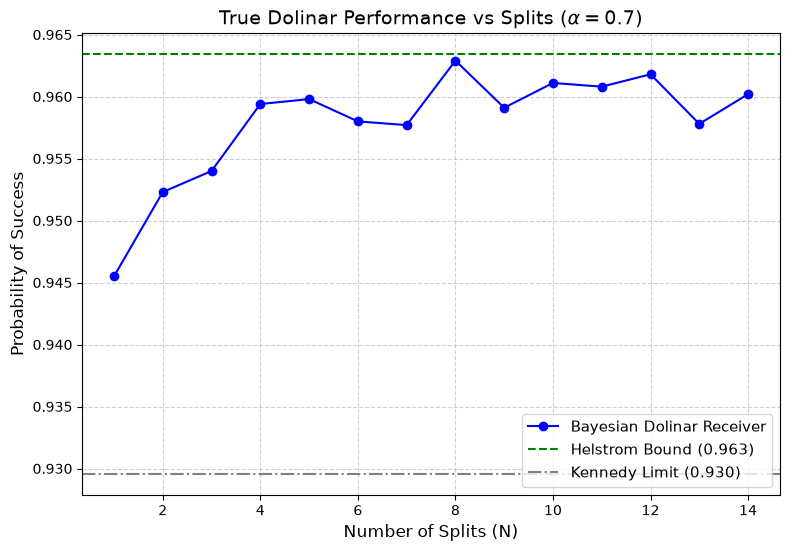

In [17]:

def bayesian_dolinar_receiver(true_signal, alpha_magnitude, num_splits, dark_count_rate=0.0):
    alpha_s = alpha_magnitude / np.sqrt(num_splits)
    P_plus = 0.5 #50/50 prob
    for _ in range(num_splits):
        if P_plus >= 0.5:
            guess_sign = 1
            P_guess = P_plus
        else:
            guess_sign = -1
            P_guess = 1.0 - P_plus
        if P_guess > 0.99999:
            beta = 0.0 #p_guess is almost certain, no extra displacement needed
        else:
            rhs = np.log(P_guess / (1.0 - P_guess))
            def func(b):
                return np.log((2*alpha_s + b)/b) - 4*alpha_s**2 - 4*alpha_s*b - rhs
            try:
                res = root_scalar(func, bracket=[1e-12, 4.0])
                beta = res.root
            except ValueError:
                beta = 0.0
                print("Warning: No root found for beta, setting beta to 0.0")
        disp = -guess_sign * (alpha_s + beta)
        gamma_actual = true_signal/np.sqrt(num_splits) + disp
        p0_actual = np.exp(-np.abs(gamma_actual)**2) * (1.0 - dark_count_rate)
        clicked = np.random.rand() > p0_actual
        gamma_if_plus = alpha_s + disp
        gamma_if_minus = -alpha_s + disp
        
        p0_if_plus = np.exp(-np.abs(gamma_if_plus)**2) * (1.0 - dark_count_rate)
        p0_if_minus = np.exp(-np.abs(gamma_if_minus)**2) * (1.0 - dark_count_rate)
        
        if not clicked:
            num = P_plus * p0_if_plus
            den = num + (1.0 - P_plus) * p0_if_minus
        else:
            num = P_plus * (1.0 - p0_if_plus)
            den = num + (1.0 - P_plus) * (1.0 - p0_if_minus)
        P_plus = num / den if den > 0 else (1.0 if P_plus > 0.5 else 0.0)
    return "+alpha" if P_plus >= 0.5 else "-alpha"

def evaluate_bayesian_dolinar(num_splits, alpha, runs_pr_split):
    correct_guesses = 0
    for _ in range(runs_pr_split):
        true_sign = np.random.choice([1, -1])
        true_signal = true_sign * alpha
        expected_result = "+alpha" if true_sign > 0 else "-alpha"
        
        result = bayesian_dolinar_receiver(true_signal, alpha, num_splits)
        if result == expected_result:
            correct_guesses += 1
            
    return correct_guesses / runs_pr_split

splitrange = range(1, 15)
alpha = 0.7
runs_pr_split = 10000

print("Running Bayesian Adaptive Dolinar Receiver...")
success_rates = joblib.Parallel(n_jobs=-1, prefer="threads")(
    joblib.delayed(evaluate_bayesian_dolinar)(num_splits, alpha, runs_pr_split)
    for num_splits in tqdm.tqdm(splitrange, desc="Evaluating splits")
)

kennedy_limit = 0.5 + 0.5 * (1 - np.exp(-4 * alpha**2))
helstrom_bound = 0.5 * (1 + np.sqrt(1 - np.exp(-4 * alpha**2)))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(splitrange, success_rates, marker='o', label="Bayesian Dolinar Receiver", color='blue')
ax.axhline(helstrom_bound, color='green', linestyle='--', label=f"Helstrom Bound ({helstrom_bound:.3f})")
ax.axhline(kennedy_limit, color='gray', linestyle='-.', label=f"Kennedy Limit ({kennedy_limit:.3f})")
ax.set_xlabel("Number of Splits (N)", fontsize=12)
ax.set_ylabel("Probability of Success", fontsize=12)
ax.set_title(f"True Dolinar Performance vs Splits ($\\alpha = {alpha}$)", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='lower right', fontsize=11)

In [18]:
def exact_bayesian_error(alpha, N):
    alpha_s = alpha / np.sqrt(N)
    beta_cache = {}

    def get_optimal_beta(pi):
        pi_round = round(pi, 10)
        if pi_round in beta_cache:
            return beta_cache[pi_round]
            
        pi_eff = max(pi, 1.0 - pi)
        if pi_eff > 1.0 - 1e-12:
            beta_cache[pi_round] = 0.0
            return 0.0
            
        rhs = np.log(pi_eff / (1.0 - pi_eff))
        def func(b):
            return np.log((2*alpha_s + b)/b) - 4*alpha_s**2 - 4*alpha_s*b - rhs
            
        try:
            res = root_scalar(func, bracket=[1e-12, 5.0], method='brentq')
            beta = max(0.0, res.root)
        except ValueError:
            beta = 0.0
            
        beta_cache[pi_round] = beta
        return beta

    def get_path_error(true_sign):
        state_tree = {0.5: 1.0}
        
        for step in range(N):
            next_tree = {}
            for pi, path_prob in state_tree.items():
                if path_prob < 1e-15: 
                    continue
                    
                beta = get_optimal_beta(pi)
                if pi >= 0.5:
                    guess_sign = 1
                else:
                    guess_sign = -1
                
                disp = -guess_sign * (alpha_s + beta)
                
                true_field = true_sign * alpha_s
                gamma_actual = true_field + disp
                p0_actual = np.exp(-gamma_actual**2)
                p1_actual = 1.0 - p0_actual
                
                gamma_if_plus = alpha_s + disp
                gamma_if_minus = -alpha_s + disp
                
                p0_if_plus = np.exp(-gamma_if_plus**2)
                p0_if_minus = np.exp(-gamma_if_minus**2)
                p1_if_plus = 1.0 - p0_if_plus
                p1_if_minus = 1.0 - p0_if_minus

                # branch 0
                denom0 = pi * p0_if_plus + (1.0 - pi) * p0_if_minus
                if denom0 > 0:
                    pi0 = (pi * p0_if_plus) / denom0
                    key0 = round(pi0, 10)
                    next_tree[key0] = next_tree.get(key0, 0.0) + path_prob * p0_actual

                # Branch 1
                denom1 = pi * p1_if_plus + (1.0 - pi) * p1_if_minus
                if denom1 > 0:
                    pi1 = (pi * p1_if_plus) / denom1
                    key1 = round(pi1, 10)
                    next_tree[key1] = next_tree.get(key1, 0.0) + path_prob * p1_actual

            state_tree = next_tree

        error = 0.0
        for pi, prob in state_tree.items():
            if true_sign == 1 and pi < 0.5:
                error += prob
            elif true_sign == -1 and pi > 0.5:
                error += prob
            elif pi == 0.5:
                error += 0.5 * prob
                
        return error

    err_plus = get_path_error(1)
    err_minus = get_path_error(-1)
    
    return 0.5 * err_plus + 0.5 * err_minus



In [19]:
alpha_list = [0.5, 0.7, 1.0]  
max_splits = 15
exact_errors_list = []
for alpha in alpha_list:
    # Kennedy error formula: 0.5 * exp(-4*alpha^2)
    kennedy_error = 0.5 * np.exp(-4 * alpha**2)
    # Helstrom bound formula: 0.5 * (1 - sqrt(1 - exp(-4*alpha^2)))
    helstrom_error = 0.5 * (1.0 - np.sqrt(1.0 - np.exp(-4 * alpha**2)))

    print(f"--- Analytical Bounds for alpha = {alpha} ---")
    print(f"Standard Kennedy Error: {kennedy_error * 100:.3f}%")
    print(f"Helstrom Minimum Error: {helstrom_error * 100:.3f}%\n")
    print("N Splits | Exact Error Rate | Status")
    print("-" * 45)

    N_values = list(range(1, max_splits + 1))
    exact_errors = []

    for N in N_values:
        err = exact_bayesian_error(alpha, N)
        exact_errors.append(err)

        status = "Beats Kennedy!" if err < kennedy_error else "Tied Kennedy"
        print(f"   {N:2d}    |     {err * 100:.3f}%     | {status}")

    exact_errors_list.append(exact_errors)

--- Analytical Bounds for alpha = 0.5 ---
Standard Kennedy Error: 18.394%
Helstrom Minimum Error: 10.247%

N Splits | Exact Error Rate | Status
---------------------------------------------
    1    |     13.481%     | Beats Kennedy!
    2    |     12.164%     | Beats Kennedy!
    3    |     11.654%     | Beats Kennedy!
    4    |     11.375%     | Beats Kennedy!
    5    |     11.198%     | Beats Kennedy!
    6    |     11.073%     | Beats Kennedy!
    7    |     10.980%     | Beats Kennedy!
    8    |     10.908%     | Beats Kennedy!
    9    |     10.850%     | Beats Kennedy!
   10    |     10.803%     | Beats Kennedy!
   11    |     10.763%     | Beats Kennedy!
   12    |     10.729%     | Beats Kennedy!
   13    |     10.699%     | Beats Kennedy!
   14    |     10.674%     | Beats Kennedy!
   15    |     10.651%     | Beats Kennedy!
--- Analytical Bounds for alpha = 0.7 ---
Standard Kennedy Error: 7.043%
Helstrom Minimum Error: 3.655%

N Splits | Exact Error Rate | Status
--------

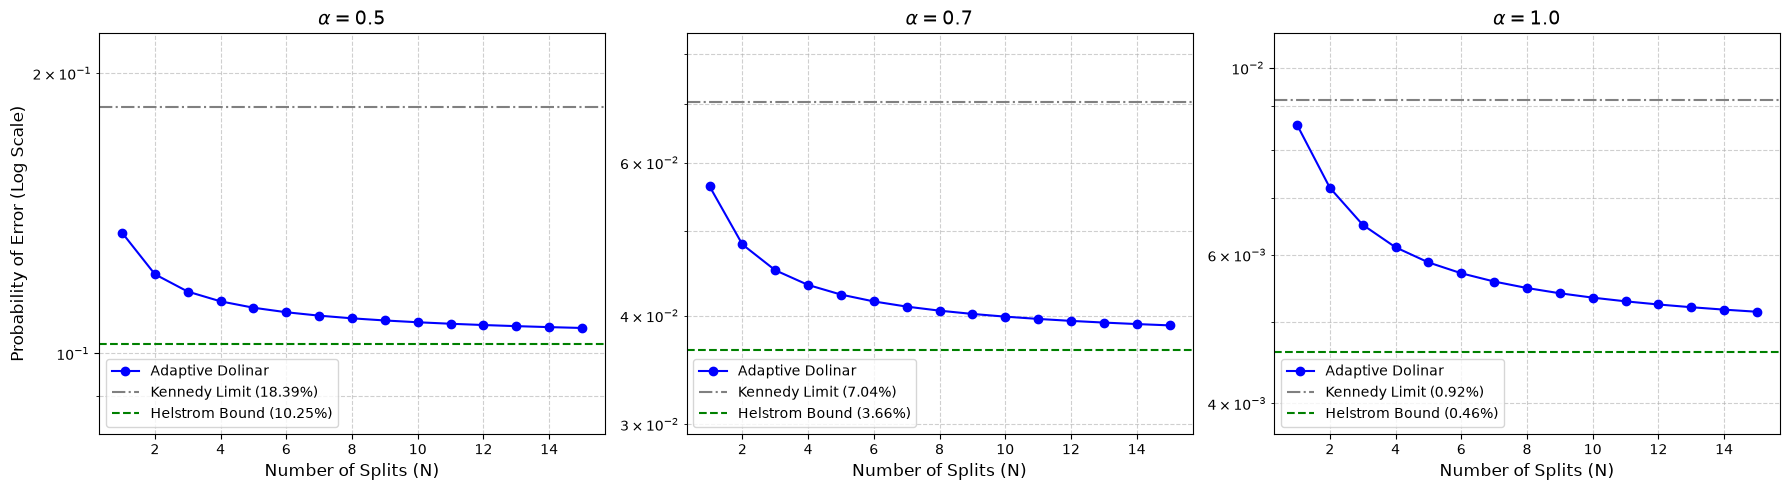

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, alpha in enumerate(alpha_list):
    exact_errors = exact_errors_list[idx]
    kennedy_error = 0.5 * np.exp(-4 * alpha**2)
    helstrom_error = 0.5 * (1.0 - np.sqrt(1.0 - np.exp(-4 * alpha**2)))
    ax = axes[idx]
    ax.semilogy(N_values, exact_errors, marker='o', color='blue', label='Adaptive Dolinar')

    ax.axhline(kennedy_error, color='gray', linestyle='-.', label=f'Kennedy Limit ({kennedy_error*100:.2f}%)')
    ax.axhline(helstrom_error, color='green', linestyle='--', label=f'Helstrom Bound ({helstrom_error*100:.2f}%)')

    ax.set_title(f"$\\alpha = {alpha}$", fontsize=14)
    ax.set_xlabel("Number of Splits (N)", fontsize=12)
    
    if idx == 0:
        ax.set_ylabel("Probability of Error (Log Scale)", fontsize=12)

    ax.set_ylim([helstrom_error * 0.8, kennedy_error * 1.2])
    
    ax.grid(True, which="both", linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.optimize import root_scalar
from joblib import Parallel, delayed
from tqdm import tqdm

def exact_bayesian_error(alpha, N):
    alpha_s = alpha / np.sqrt(N)
    beta_cache = {}
    
    def get_optimal_beta(pi):
        pi_round = round(pi, 10)
        if pi_round in beta_cache:
            return beta_cache[pi_round]
            
        pi_eff = max(pi, 1.0 - pi)
        if pi_eff > 1.0 - 1e-12:
            beta_cache[pi_round] = 0.0
            return 0.0
            
        rhs = np.log(pi_eff / (1.0 - pi_eff))
        def func(b):
            return np.log((2*alpha_s + b)/b) - 4*alpha_s**2 - 4*alpha_s*b - rhs
            
        try:
            res = root_scalar(func, bracket=[1e-12, 5.0], method='brentq')
            beta = max(0.0, res.root)
        except ValueError:
            beta = 0.0
            
        beta_cache[pi_round] = beta
        return beta

    def get_path_error(true_sign):
        state_tree = {0.5: 1.0}
        
        for step in range(N):
            next_tree = {}
            for pi, path_prob in state_tree.items():
                if path_prob < 1e-15: 
                    continue
                    
                beta = get_optimal_beta(pi)
                guess_sign = 1 if pi >= 0.5 else -1
                disp = -guess_sign * (alpha_s + beta)
                
                true_field = true_sign * alpha_s
                gamma_actual = true_field + disp
                p0_actual = np.exp(-gamma_actual**2)
                p1_actual = 1.0 - p0_actual
                
                gamma_if_plus = alpha_s + disp
                gamma_if_minus = -alpha_s + disp
                
                p0_if_plus = np.exp(-gamma_if_plus**2)
                p0_if_minus = np.exp(-gamma_if_minus**2)
                p1_if_plus = 1.0 - p0_if_plus
                p1_if_minus = 1.0 - p0_if_minus

                denom0 = pi * p0_if_plus + (1.0 - pi) * p0_if_minus
                if denom0 > 0:
                    pi0 = (pi * p0_if_plus) / denom0
                    key0 = round(pi0, 10)
                    next_tree[key0] = next_tree.get(key0, 0.0) + path_prob * p0_actual

                denom1 = pi * p1_if_plus + (1.0 - pi) * p1_if_minus
                if denom1 > 0:
                    pi1 = (pi * p1_if_plus) / denom1
                    key1 = round(pi1, 10)
                    next_tree[key1] = next_tree.get(key1, 0.0) + path_prob * p1_actual

            state_tree = next_tree

        error = 0.0
        for pi, prob in state_tree.items():
            if true_sign == 1 and pi < 0.5:
                error += prob
            elif true_sign == -1 and pi > 0.5:
                error += prob
            elif pi == 0.5:
                error += 0.5 * prob
                
        return error

    err_plus = get_path_error(1)
    err_minus = get_path_error(-1)
    return 0.5 * err_plus + 0.5 * err_minus

alpha_values = np.linspace(0.3, 1.4, 20)
max_splits = 15
N_values = range(5, max_splits + 1)

kennedy_bers = [0.5 * np.exp(-4 * alpha**2) for alpha in alpha_values]
helstrom_bers = [0.5 * (1.0 - np.sqrt(1.0 - np.exp(-4 * alpha**2))) for alpha in alpha_values]

tasks = [(alpha, N) for alpha in alpha_values for N in N_values]

parallel_generator = Parallel(n_jobs=-1, return_as="generator")(
    delayed(exact_bayesian_error)(alpha, N) for alpha, N in tasks
)

results = list(tqdm(parallel_generator, total=len(tasks), desc="Computing Dolinar BERs"))

dolinar_bers = {N: [] for N in N_values}
for (alpha, N), error in zip(tasks, results):
    dolinar_bers[N].append(error)

Computing Dolinar BERs: 100%|██████████| 220/220 [00:26<00:00,  8.16it/s]


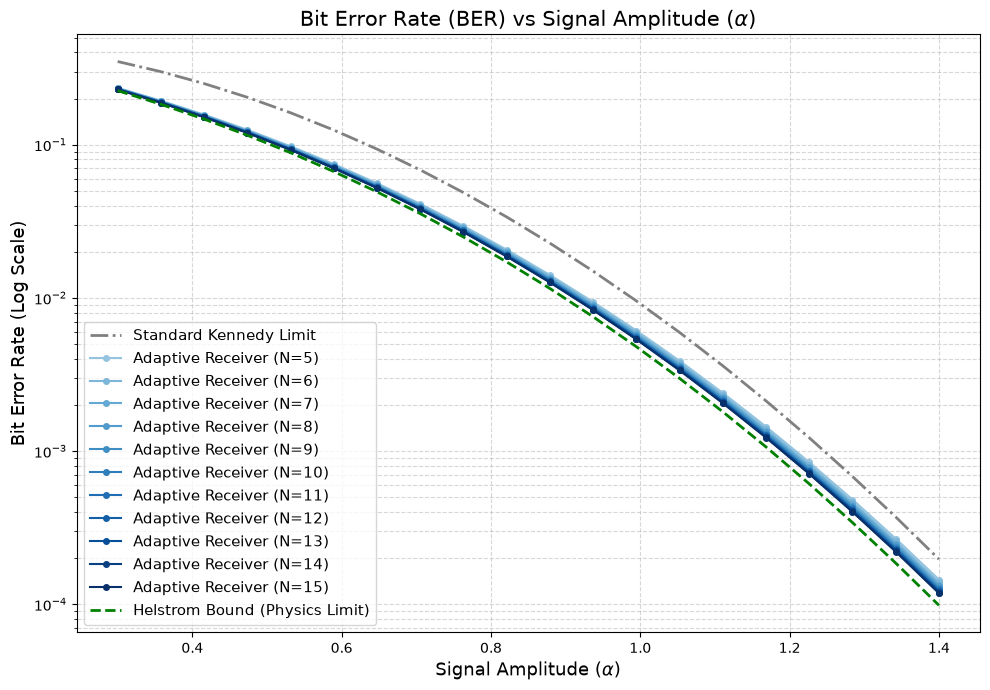

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.semilogy(alpha_values, kennedy_bers, color='gray', linestyle='-.', linewidth=2, label='Standard Kennedy Limit')

colors = plt.cm.Blues(np.linspace(0.4, 1.0, max_splits - 4))
for N, color in zip(range(5, max_splits + 1), colors):
    ax.semilogy(alpha_values, dolinar_bers[N], marker='o', markersize=4, color=color, label=f'Adaptive Receiver (N={N})')

ax.semilogy(alpha_values, helstrom_bers, color='green', linestyle='--', linewidth=2, label='Helstrom Bound (Physics Limit)')

ax.set_title("Bit Error Rate (BER) vs Signal Amplitude ($\\alpha$)", fontsize=15)
ax.set_xlabel("Signal Amplitude ($\\alpha$)", fontsize=13)
ax.set_ylabel("Bit Error Rate (Log Scale)", fontsize=13)

ax.grid(True, which="both", linestyle='--', alpha=0.5)
ax.legend(fontsize=11, loc='lower left')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.optimize import root_scalar
from joblib import Parallel, delayed
from tqdm import tqdm

def exact_bayesian_error(alpha, N, disp_noise_factor=0.0, efficiency=1.0, dark_count_prob=0.0):
    alpha_s = alpha / np.sqrt(N)
    beta_cache = {}
    
    def get_expected_p0(mu_int, sigma_disp):
        
        variance_term = 1.0 + 2.0 * efficiency * sigma_disp**2
        exp_term = np.exp(- (efficiency * mu_int**2) / variance_term)
        
        return (1.0 - dark_count_prob) * (1.0 / np.sqrt(variance_term)) * exp_term

    def get_optimal_beta(pi):
        pi_round = round(pi, 10)
        if pi_round in beta_cache:
            return beta_cache[pi_round]
            
        pi_eff = max(pi, 1.0 - pi)
        if pi_eff > 1.0 - 1e-12:
            beta_cache[pi_round] = 0.0
            return 0.0
            
        rhs = np.log(pi_eff / (1.0 - pi_eff))
        def func(b):
            return np.log((2*alpha_s + b)/b) - 4*alpha_s**2 - 4*alpha_s*b - rhs
            
        try:
            res = root_scalar(func, bracket=[1e-12, 5.0], method='brentq')
            beta = max(0.0, res.root)
        except ValueError:
            beta = 0.0
            
        beta_cache[pi_round] = beta
        return beta

    def get_path_error(true_sign):
        state_tree = {0.5: 1.0}
        
        for step in range(N):
            next_tree = {}
            for pi, path_prob in state_tree.items():
                if path_prob < 1e-15: 
                    continue
                    
                beta = get_optimal_beta(pi)
                
                sigma_disp = disp_noise_factor * beta
                
                guess_sign = 1 if pi >= 0.5 else -1
                disp_intended = -guess_sign * (alpha_s + beta)
                
                true_field = true_sign * alpha_s
                mu_actual = true_field + disp_intended
                
                p0_actual = get_expected_p0(mu_actual, sigma_disp)
                p1_actual = 1.0 - p0_actual
                
                mu_if_plus = alpha_s + disp_intended
                mu_if_minus = -alpha_s + disp_intended
                
                p0_if_plus = get_expected_p0(mu_if_plus, sigma_disp)
                p0_if_minus = get_expected_p0(mu_if_minus, sigma_disp)
                
                p1_if_plus = 1.0 - p0_if_plus
                p1_if_minus = 1.0 - p0_if_minus

                denom0 = pi * p0_if_plus + (1.0 - pi) * p0_if_minus
                if denom0 > 0:
                    pi0 = (pi * p0_if_plus) / denom0
                    key0 = round(pi0, 10)
                    next_tree[key0] = next_tree.get(key0, 0.0) + path_prob * p0_actual

                denom1 = pi * p1_if_plus + (1.0 - pi) * p1_if_minus
                if denom1 > 0:
                    pi1 = (pi * p1_if_plus) / denom1
                    key1 = round(pi1, 10)
                    next_tree[key1] = next_tree.get(key1, 0.0) + path_prob * p1_actual

            state_tree = next_tree

        error = 0.0
        for pi, prob in state_tree.items():
            if true_sign == 1 and pi < 0.5:
                error += prob
            elif true_sign == -1 and pi > 0.5:
                error += prob
            elif pi == 0.5:
                error += 0.5 * prob
                
        return error

    err_plus = get_path_error(1)
    err_minus = get_path_error(-1)
    return 0.5 * err_plus + 0.5 * err_minus

alpha_values = np.linspace(0.3, 1.6, 22)
max_splits = 10
N_values = range(1, max_splits + 1)

DISP_NOISE_FACTOR = 0.02   # Standard deviation of displacement error is 2% of the optimal beta
EFFICIENCY = 0.95         # 95% probability of detecting a photon that is actually there
DARK_COUNT_PROB = 1e-4    # 0.01% baseline chance to register a click when field is 0

kennedy_bers = [0.5 * np.exp(-4 * alpha**2) for alpha in alpha_values]
helstrom_bers = [0.5 * (1.0 - np.sqrt(1.0 - np.exp(-4 * alpha**2))) for alpha in alpha_values]

tasks = [(alpha, N, DISP_NOISE_FACTOR, EFFICIENCY, DARK_COUNT_PROB) 
         for alpha in alpha_values for N in N_values]

parallel_generator = Parallel(n_jobs=-1, return_as="generator")(
    delayed(exact_bayesian_error)(alpha, N, noise, eff, dark_count) 
    for alpha, N, noise, eff, dark_count in tasks
)

results = list(tqdm(parallel_generator, total=len(tasks), desc="Computing Imperfect Dolinar BERs"))

dolinar_bers = {N: [] for N in N_values}
for (alpha, N, _, _, _), error in zip(tasks, results):
    dolinar_bers[N].append(error)

Computing Imperfect Dolinar BERs: 100%|██████████| 220/220 [00:00<00:00, 300.83it/s]


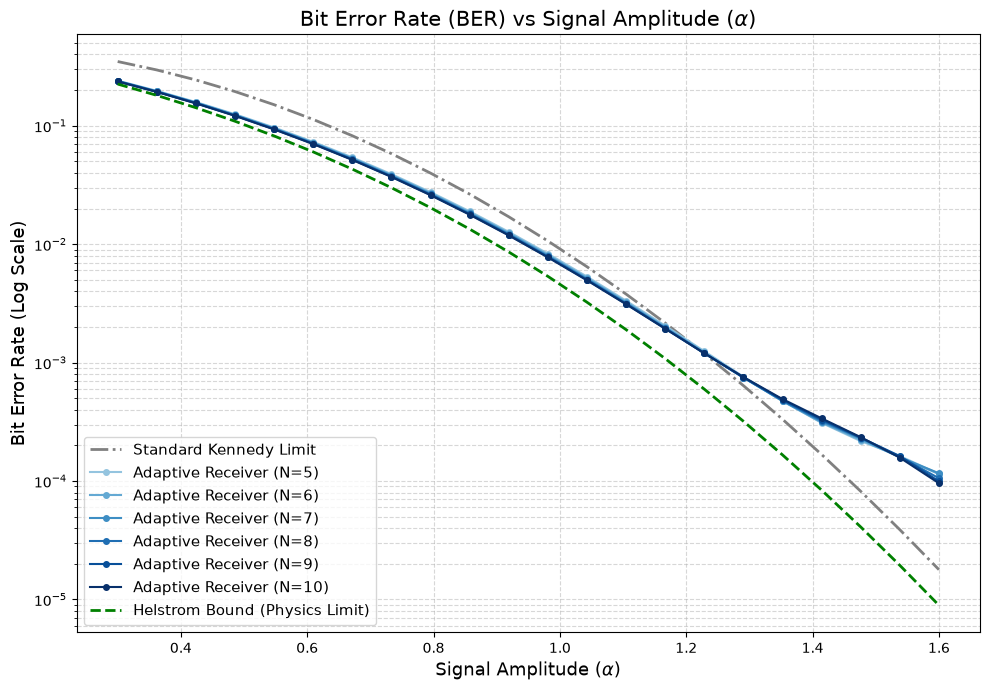

In [48]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.semilogy(alpha_values, kennedy_bers, color='gray', linestyle='-.', linewidth=2, label='Standard Kennedy Limit')

colors = plt.cm.Blues(np.linspace(0.4, 1.0, max_splits - 4))
for N, color in zip(range(5, max_splits + 1), colors):
    ax.semilogy(alpha_values, dolinar_bers[N], marker='o', markersize=4, color=color, label=f'Adaptive Receiver (N={N})')

ax.semilogy(alpha_values, helstrom_bers, color='green', linestyle='--', linewidth=2, label='Helstrom Bound (Physics Limit)')

ax.set_title("Bit Error Rate (BER) vs Signal Amplitude ($\\alpha$)", fontsize=15)
ax.set_xlabel("Signal Amplitude ($\\alpha$)", fontsize=13)
ax.set_ylabel("Bit Error Rate (Log Scale)", fontsize=13)

ax.grid(True, which="both", linestyle='--', alpha=0.5)
ax.legend(fontsize=11, loc='lower left')

plt.tight_layout()
plt.show()

In [75]:
def fast_qpsk_homodyne_monte_carlo(alpha, N, n_paths=100000):
    # 4 coherent states at phases: 0, pi/2, pi, 3pi/2
    phases = np.array([0.0, np.pi/2, np.pi, 3*np.pi/2])
    
    # Signal amplitude per slice
    alpha_s = alpha / np.sqrt(N)
    variance = 0.5  # Standard homodyne vacuum noise variance (depends on convention)
    std_dev = np.sqrt(variance)
    
    # Assume the true state is State 0 (phase = 0). 
    # Because of symmetry, we only need to simulate one true state.
    true_phase = phases[0]
    
    # Track the Bayesian prior probabilities for all 4 states across all paths
    # Shape: (n_paths, 4). Initial belief is 25% for each state.
    P_bayesian = np.ones((n_paths, 4)) * 0.25
    
    # Track the current Local Oscillator (LO) phase for each path
    # Usually, we start by measuring the X quadrature (LO = 0) or diagonal (LO = pi/4)
    lo_phases = np.zeros(n_paths) + np.pi/4 

    for step in range(N):
        # 1. PHYSICAL MEASUREMENT: 
        # The true mean of the homodyne measurement is proportional to cos(true_phase - lo_phase)
        true_mean = np.sqrt(2) * alpha_s * np.cos(true_phase - lo_phases)
        
        # Draw continuous homodyne outcomes for all 100,000 paths at once!
        x_measurements = np.random.normal(loc=true_mean, scale=std_dev)
        
        # 2. BAYESIAN UPDATE:
        # Calculate how likely this measurement was under all 4 possible state hypotheses
        # Using the Gaussian PDF: exp(-(x - mean)^2 / (2 * variance))
        for i, hyp_phase in enumerate(phases):
            hyp_mean = np.sqrt(2) * alpha_s * np.cos(hyp_phase - lo_phases)
            
            # Probability of seeing 'x' given state 'i'
            likelihood = np.exp(-0.5 * ((x_measurements - hyp_mean) / std_dev)**2)
            
            # Update belief (Prior * Likelihood)
            P_bayesian[:, i] *= likelihood
            
        # Normalize probabilities across the 4 states so they sum to 1
        P_bayesian /= np.sum(P_bayesian, axis=1, keepdims=True)
        
        # 3. ADAPT THE LOCAL OSCILLATOR (The "Dolinar" equivalent step)
        # For QPSK, a common heuristic is to set the LO phase to be orthogonal 
        # to the average expected phase to maximize discrimination on the next slice.
        expected_sin = np.sum(P_bayesian * np.sin(phases), axis=1)
        expected_cos = np.sum(P_bayesian * np.cos(phases), axis=1)
        avg_phase = np.arctan2(expected_sin, expected_cos)
        
        # Shift LO by 90 degrees from the current estimate to differentiate remaining ambiguity
        lo_phases = avg_phase + np.pi/2

    # 4. FINAL DECISION
    # The chosen state is the one with the highest final Bayesian probability
    guessed_states = np.argmax(P_bayesian, axis=1)
    
    # Error occurs if the guessed state is not State 0
    errors = np.sum(guessed_states != 0)
    
    return errors / n_paths

# Example execution:
alpha = 0.2
N_slices = 100
ber = fast_qpsk_homodyne_monte_carlo(alpha, N_slices, n_paths=100000)
print(f"Error Rate for QPSK Homodyne (alpha={alpha}): {ber:.5f}")

Error Rate for QPSK Homodyne (alpha=0.2): 0.65228
